In [2]:

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [12]:
df=pd.read_csv(r"C:\Users\NARENDRA\Downloads\4. Logistic Regresssion - Assignment - 3\4. Logistic Regresssion\bank-full.csv",sep=";", quotechar='"')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [13]:
print(df.shape)

(45211, 17)


In [14]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [15]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [16]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


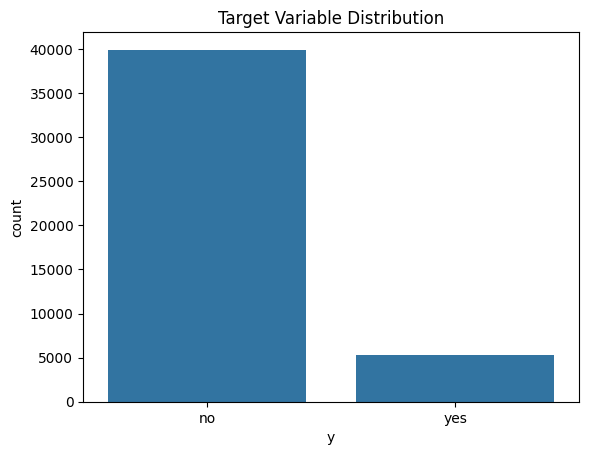

y
no     39922
yes     5289
Name: count, dtype: int64


In [17]:

sns.countplot(data=df, x="y")

plt.title("Target Variable Distribution")

plt.show()

print(df["y"].value_counts())

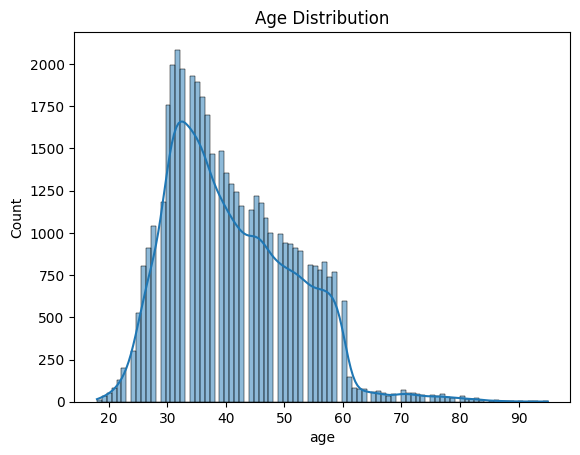

In [18]:


sns.histplot(df["age"], kde=True)

plt.title("Age Distribution")

plt.show()

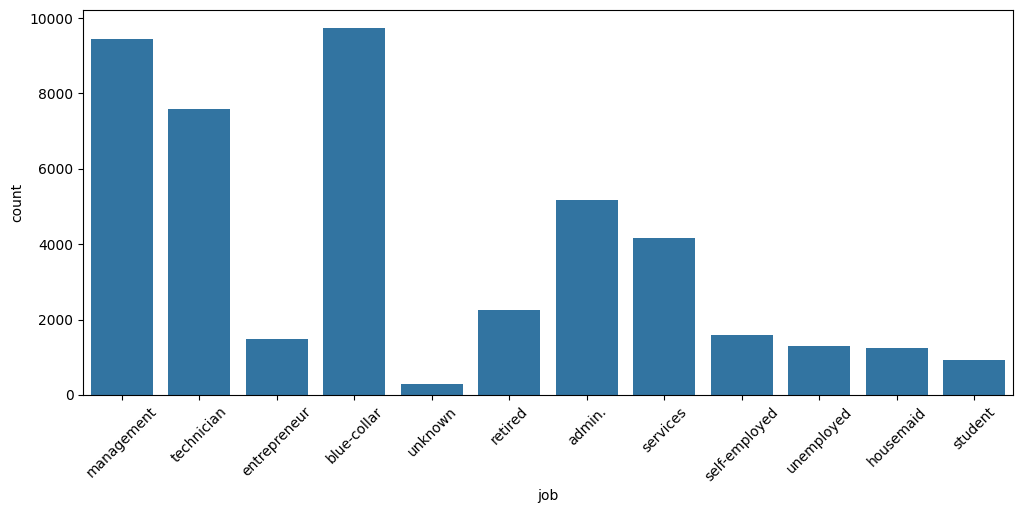

In [20]:


plt.figure(figsize=(12,5))

sns.countplot(data=df,x="job")

plt.xticks(rotation=45)

plt.show()

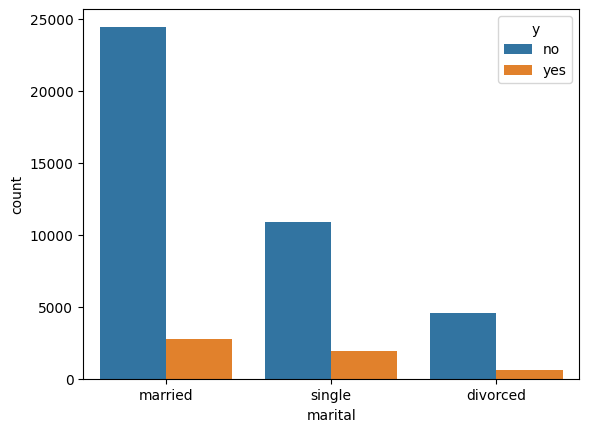

In [21]:


sns.countplot(data=df,x="marital",hue="y")

plt.show()

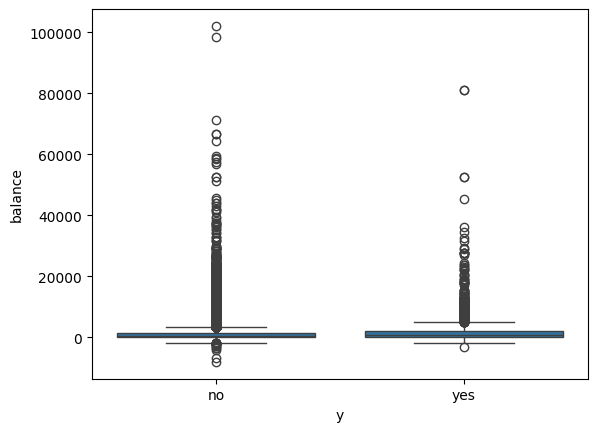

In [22]:


sns.boxplot(data=df,x="y",y="balance")

plt.show()

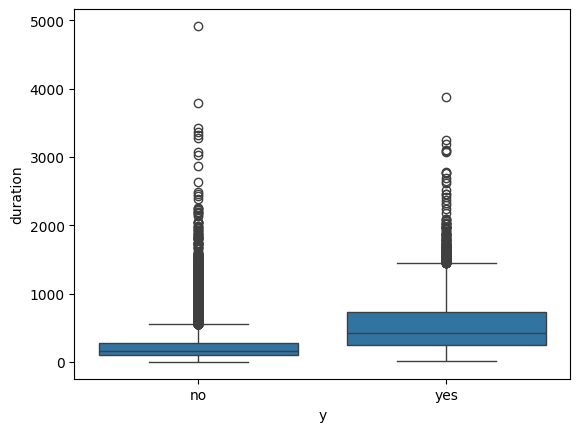

In [23]:


sns.boxplot(
    data=df,
    x="y",
    y="duration"
)

plt.show()

In [24]:


le = LabelEncoder()

df["y"] = le.fit_transform(df["y"])

print(df["y"].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [25]:


df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print(df_encoded.shape)

df_encoded.head()

(45211, 43)


,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,0,False,True,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,0,False,False,...,False,False,False,True,False,False,False,False,False,True


In [26]:

X = df_encoded.drop("y", axis=1)

y = df_encoded["y"]

In [27]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:


lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(X_test)

C:\Users\NARENDRA\anaconda3\envs\AI\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:


lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression Accuracy:")
print(lr_accuracy)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy:
0.8980426849496849
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7952
           1       0.66      0.31      0.43      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.65      0.68      9043
weighted avg       0.88      0.90      0.88      9043



In [30]:


rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [31]:

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:")
print(rf_accuracy)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy:
0.9037929890523057
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.67      0.40      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.80      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



In [32]:
# Model Comparison

print("Logistic Regression Accuracy =", lr_accuracy)

print("Random Forest Accuracy =", rf_accuracy)

Logistic Regression Accuracy = 0.8980426849496849
Random Forest Accuracy = 0.9037929890523057


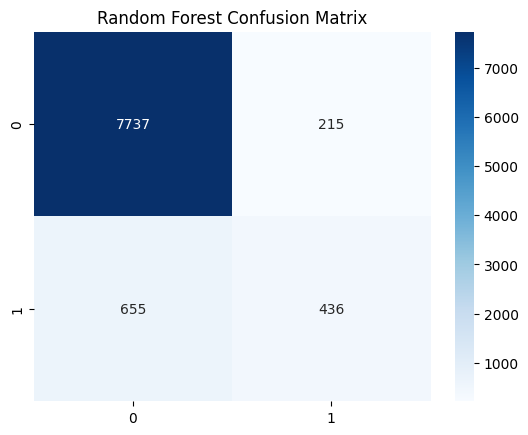

In [33]:


cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

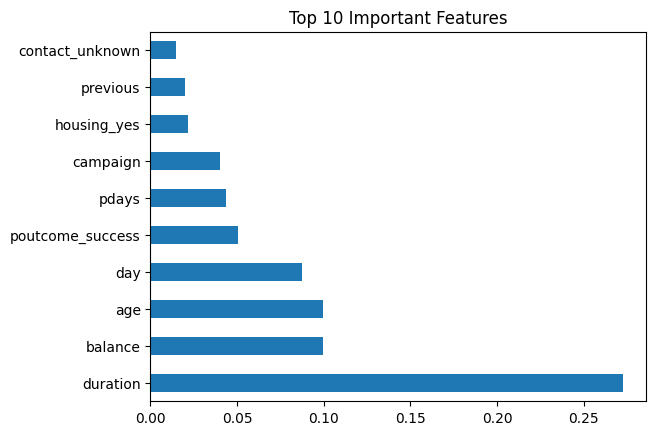

In [34]:



importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.nlargest(10).plot(
    kind="barh"
)

plt.title("Top 10 Important Features")

plt.show()

In [35]:


sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("Client likely to subscribe")
else:
    print("Client not likely to subscribe")

Client not likely to subscribe
